# PCA on Neural Populations

### NEUBEH/PBIO 545 — Quantitative Methods in Neuroscience

*Adapted from* [`matlab/PCANeuroPopTutorial.m`](../matlab/PCANeuroPopTutorial.m).

This tutorial introduces **principal components analysis** as a tool for understanding the
*geometry* of neural population responses. It is a companion to `PCATutorial.m`, which
applies PCA to variability in single-cell recordings. Here the
emphasis shifts from *variability* to *structure*: what shape does a population's activity
trace out as a stimulus changes?

The tutorial builds in five stages:

| Part | Topic |
|---|---|
| I | Why neural populations live in low-dimensional subspaces |
| II | Covariance and its eigensystem — the mathematical backbone of PCA |
| III | PCA on a simulated orientation-tuning population |
| IV | PCA with two-dimensional stimuli (orientation × spatial frequency) |
| V | Fixed-axis projection — comparing two populations in a common space |

Run it cell by cell (**Shift+Enter**). Read the text carefully — the narrative and the
homework problems are part of the tutorial, not decoration.

**Prerequisites:** the linear algebra tutorial, and `PCATutorial.m`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3-D projection)

rng = np.random.default_rng(42)   # fixed seed, so every run reproduces the figures

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
    "font.size": 10,
})

def set_axes_equal(ax, data=None):
    '''Equal aspect ratio for a 3-D axis (matplotlib has no 'axis equal' in 3-D).

    Pass `data` (an (n, 3) array) to set the limits from that array rather than
    from what is currently drawn. Giving two axes the SAME data is how you make
    two 3-D panels genuinely comparable -- see Part V.
    '''
    if data is None:
        limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    else:
        limits = np.column_stack([np.min(data, axis=0), np.max(data, axis=0)])
    centers = limits.mean(axis=1)
    radius = 0.5 * (limits[:, 1] - limits[:, 0]).max()
    for setter, c in zip([ax.set_xlim3d, ax.set_ylim3d, ax.set_zlim3d], centers):
        setter(c - radius, c + radius)


def plot_manifold(ax, sc, point_colors, n_o, n_f, s=55):
    '''Draw a 2-D stimulus manifold in the top 3 PCs as a mesh.

    `sc` has shape (n_o * n_f, K) in orientation-major order, so reshaping to
    (n_o, n_f, 3) puts orientation along axis 0 and spatial frequency along
    axis 1. We draw a closed loop along the orientation direction at each SF
    (the rings) and an open line along the SF direction at each orientation.
    Drawing the mesh instead of one polyline through the conditions in order
    is what makes the torus legible.
    '''
    G = sc[:, :3].reshape(n_o, n_f, 3)
    for f in range(n_f):
        loop = np.vstack([G[:, f, :], G[0, f, :]])
        ax.plot(loop[:, 0], loop[:, 1], loop[:, 2], "-k", lw=0.7, alpha=0.5)
    for o in range(n_o):
        ax.plot(G[o, :, 0], G[o, :, 1], G[o, :, 2], "-", color="0.55", lw=0.5, alpha=0.5)
    ax.scatter(sc[:, 0], sc[:, 1], sc[:, 2], s=s, c=point_colors,
               edgecolors="k", linewidths=0.3, depthshade=False)
    ax.view_init(elev=22, azim=-62)

---
## Part I. Motivation: why neural data is high-dimensional but structured

Suppose you record simultaneously from $N$ neurons while showing a visual stimulus. Each
neuron's response at one moment is a single number, so the combined state of the population
at that moment is a **point in an $N$-dimensional space** — one axis per neuron.

If $N = 300$, the population state lives in a 300-dimensional space. That sounds
intractable. But neurons are not independent: they share inputs, sit in the same circuit,
and respond to common stimulus features. Those shared influences mean the population does
**not** wander freely through all 300 dimensions. Its responses instead cluster near a
low-dimensional surface — a *manifold* — embedded in that large space.

PCA is a principled way to find the orientation of that manifold. It answers: *what are the
directions in neuron-space along which the population varies the most?*

To build intuition, start with a two-neuron "population", where everything can be drawn
directly.

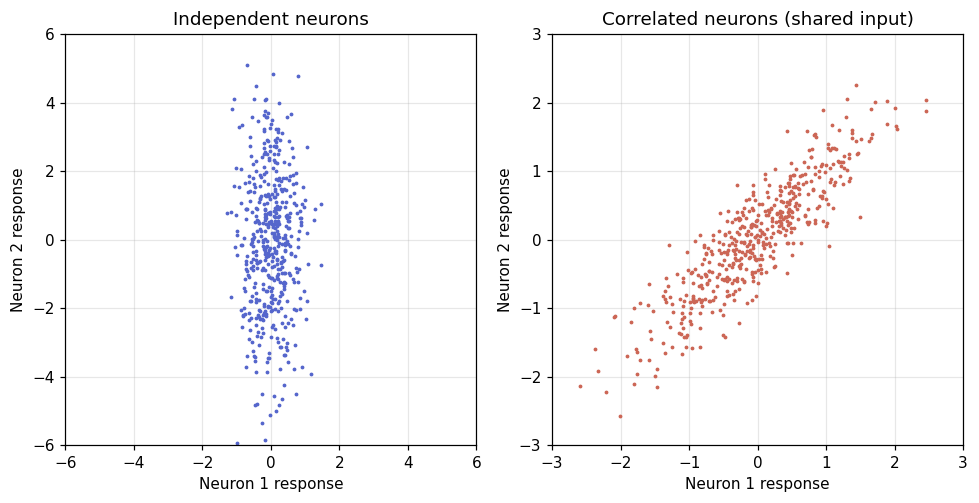

In [2]:
n_samples = 500

# --- Example 1: two neurons with independent responses (different SDs) ---
neuron1 = rng.standard_normal(n_samples) * 0.5
neuron2 = rng.standard_normal(n_samples) * 2.0
dist_indep = np.column_stack([neuron1, neuron2])

# --- Example 2: two neurons sharing a common input ---
common  = rng.standard_normal(n_samples)
private = rng.standard_normal(n_samples)
dist_corr = np.column_stack([0.8 * common + 0.2 * private,
                             0.8 * common - 0.2 * private])

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, D, title, color, lim in [
    (axes[0], dist_indep, "Independent neurons",           "#5566cc", 6),
    (axes[1], dist_corr,  "Correlated neurons (shared input)", "#cc6655", 3)]:
    ax.plot(D[:, 0], D[:, 1], ".", ms=3, color=color)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), aspect="equal",
           xlabel="Neuron 1 response", ylabel="Neuron 2 response", title=title)
fig.tight_layout()

The independent cloud is **axis-aligned**: knowing neuron 1's response tells you nothing
about neuron 2. The natural axes of that distribution are the $x$ and $y$ axes themselves.

The correlated cloud is **elongated along the diagonal**. Its natural axes are rotated away
from the coordinate axes. PCA is the procedure that finds them.

> ### Homework question 1
> **(a)** What does the orientation of the elongated cloud tell you about the relationship
> between the two neurons?
>
> **(b)** If the common input were much stronger than the private noise, what shape would
> the cloud approach? What does PCA return in that limit?
>
> **(c)** What would the cloud look like if `neuron2 = -neuron1 + noise`? How would PCA
> change?

---
## Part II. The covariance matrix and its eigensystem

The covariance matrix captures pairwise relationships between all pairs of neurons. For a
population recorded over many stimuli (or trials), the $(i,j)$ entry is

$$\mathrm{Cov}(i,j) = \langle r_i r_j \rangle - \langle r_i \rangle \langle r_j \rangle$$

where $\langle\cdot\rangle$ is the average across observations. Diagonal entries are each
neuron's variance; off-diagonal entries say how much two neurons co-vary.

⚠️ **A NumPy gotcha.** MATLAB's `cov(X)` treats **rows** as observations. NumPy's
`np.cov(X)` treats **rows as variables** by default. Either transpose, or pass
`rowvar=False`. Getting this backwards on a 300-neuron dataset produces a matrix of the
wrong size and an immediate error; getting it backwards on a square dataset produces a
wrong answer *silently*.

In [3]:
C_indep = np.cov(dist_indep, rowvar=False)   # rowvar=False -> rows are observations
C_corr  = np.cov(dist_corr,  rowvar=False)

np.set_printoptions(precision=3, suppress=True)
print("Covariance matrix, independent neurons:\n", C_indep)
print("\nCovariance matrix, correlated neurons:\n", C_corr)

Covariance matrix, independent neurons:
 [[ 0.23  -0.009]
 [-0.009  4.148]]

Covariance matrix, correlated neurons:
 [[0.702 0.627]
 [0.627 0.713]]


For the independent case the off-diagonal entries are near zero (sampling noise only). For
the correlated case they are large and positive, reflecting the shared drive.

The key fact: the **eigenvectors** of the covariance matrix point along the natural axes of
the data cloud, and the corresponding **eigenvalues** give the variance along each axis.

We use `np.linalg.eigh` rather than `eig` because a covariance matrix is symmetric — `eigh`
exploits that, is faster, and returns strictly real results. Like MATLAB's `eig`, it does
not guarantee any particular ordering, so we sort by descending eigenvalue ourselves.

Eigenvalues (independent): 4.148, 0.230
Eigenvalues (correlated):  1.335, 0.080


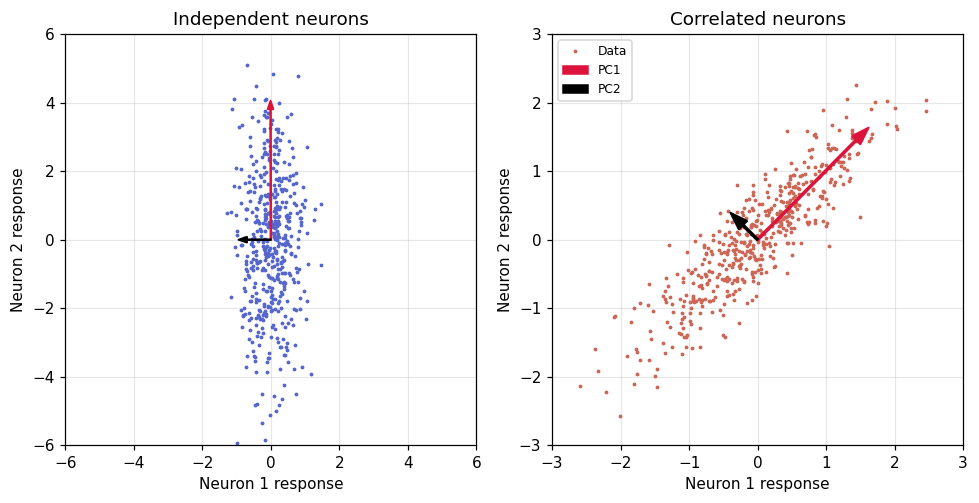

In [4]:
def sorted_eig(C):
    '''Eigenvalues/vectors of a symmetric matrix, sorted by descending eigenvalue.'''
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    return vals[order], vecs[:, order]

d_indep, V_indep = sorted_eig(C_indep)
d_corr,  V_corr  = sorted_eig(C_corr)

print(f"Eigenvalues (independent): {d_indep[0]:.3f}, {d_indep[1]:.3f}")
print(f"Eigenvalues (correlated):  {d_corr[0]:.3f}, {d_corr[1]:.3f}")

# Superimpose the eigenvectors on the scatter plots, scaled by sqrt(eigenvalue)
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
scale = 2.0
for ax, D, vals, vecs, title, color, lim in [
    (axes[0], dist_indep, d_indep, V_indep, "Independent neurons", "#5566cc", 6),
    (axes[1], dist_corr,  d_corr,  V_corr,  "Correlated neurons",  "#cc6655", 3)]:
    ax.plot(D[:, 0], D[:, 1], ".", ms=3, color=color, label="Data")
    for k, (arrow_color, name) in enumerate([("crimson", "PC1"), ("black", "PC2")]):
        v = vecs[:, k] * np.sqrt(vals[k]) * scale
        ax.arrow(0, 0, v[0], v[1], color=arrow_color, width=0.03,
                 length_includes_head=True, head_width=0.18, label=name, zorder=5)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), aspect="equal",
           xlabel="Neuron 1 response", ylabel="Neuron 2 response", title=title)
axes[1].legend(loc="upper left", fontsize=8)
fig.tight_layout()

For the independent case the eigenvectors line up with the coordinate axes, as expected.
For the correlated case they are rotated about 45°, aligned with the long axis of the
cloud.

> ### Homework question 2
> **(a)** Each arrow is scaled by $\sqrt{\lambda}$. Why is that a meaningful choice? What
> does it represent geometrically?
>
> **(b)** The total variance of the population equals the sum of the eigenvalues. Verify
> this for both distributions using `np.trace(C)` and `d.sum()`.
>
> **(c)** PCA is equivalent to rotating the coordinate axes so that the covariance matrix
> becomes *diagonal* in the new frame. Convince yourself by computing `V.T @ C @ V` for the
> correlated case. What do you find, and how does it relate to the eigenvalues?

---
## Part III. PCA on a simulated orientation-tuning population

Now to a realistic setting: a population of $N$ neurons tuned to stimulus orientation. This
mirrors a cortical recording in which many V1 neurons respond to oriented gratings with
different preferred orientations.

Each neuron has a von Mises-like tuning curve, periodic with **180°** (a grating at 0° looks
identical to one at 180°, which is why the factor of 2 appears inside the cosine):

$$R(n,s) = \text{baseline} + \text{gain}\cdot\exp\!\big[\kappa \cos\big(2(\theta_s - \phi_n)\big)\big]$$

where $\phi_n$ is neuron $n$'s preferred orientation and $\kappa$ sets the tuning width —
larger $\kappa$ means sharper tuning.

In [5]:
N        = 300            # number of neurons
baseline = 0.1            # baseline response (e.g. dF/F, or normalized rate)
gain     = 1.0            # response gain
kappa    = 3.0            # tuning concentration

pref_oris = np.linspace(0, 179.9, N)      # preferred orientations, degrees
stim_oris = np.arange(0, 180, 1.0)        # 180 stimulus orientations, 1-deg steps
S = stim_oris.size

def population_response(pref_oris, kappa, stim_oris, baseline, gain, normalize=True):
    '''Von Mises orientation tuning, 180-deg periodic. Returns R with shape (N, S).

    Note the broadcasting: pref_oris[:, None] has shape (N, 1) and stim_oris[None, :]
    has shape (1, S), so their difference is the full (N, S) grid without any loop.
    '''
    kappa = np.atleast_1d(kappa)
    if kappa.size == 1:
        kappa = np.full(pref_oris.shape, kappa.item())
    dtheta = np.deg2rad(stim_oris)[None, :] - np.deg2rad(pref_oris)[:, None]
    R = baseline + gain * np.exp(kappa[:, None] * np.cos(2 * dtheta))
    if normalize:
        # Scale each neuron so its maximum equals baseline + gain. This removes
        # differences in absolute firing rate and isolates the SHAPE of the code.
        R = R / R.max(axis=1, keepdims=True) * (baseline + gain)
    return R

R = population_response(pref_oris, kappa, stim_oris, baseline, gain)
print(f"Population response matrix R: {R.shape[0]} neurons x {R.shape[1]} stimuli")

Population response matrix R: 300 neurons x 180 stimuli


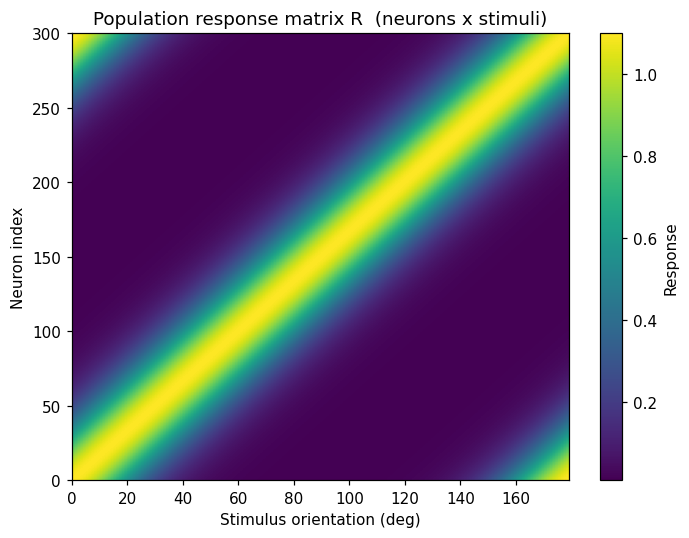

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(R, aspect="auto", origin="lower", cmap="viridis",
               extent=[stim_oris[0], stim_oris[-1], 0, N])
ax.set(xlabel="Stimulus orientation (deg)", ylabel="Neuron index",
       title="Population response matrix R  (neurons x stimuli)")
ax.grid(False)
fig.colorbar(im, ax=ax, label="Response")
fig.tight_layout()

Each row is one neuron's tuning curve. The bright diagonal band is each neuron responding
when the stimulus matches its preference. Because preferred orientations tile 0–180°
uniformly, that band sweeps steadily up the matrix.

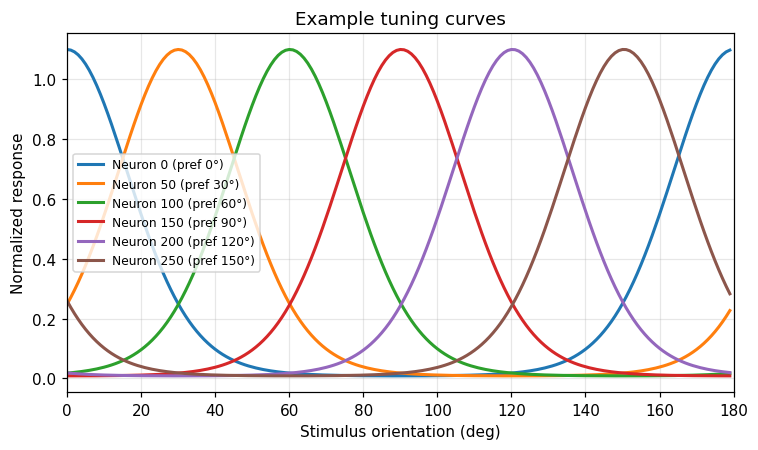

In [7]:
example_neurons = [0, 50, 100, 150, 200, 250]
colors = cm.tab10(np.linspace(0, 1, 10))

fig, ax = plt.subplots(figsize=(7, 4.2))
for i, n in enumerate(example_neurons):
    ax.plot(stim_oris, R[n], lw=2, color=colors[i],
            label=f"Neuron {n} (pref {pref_oris[n]:.0f}°)")
ax.set(xlabel="Stimulus orientation (deg)", ylabel="Normalized response",
       title="Example tuning curves", xlim=(0, 180))
ax.legend(fontsize=8)
fig.tight_layout()

### Running PCA

**Convention.** Rows of the data matrix `X` are *observations* (here, stimuli); columns are
*features* (here, neurons). Our response matrix `R` is (neurons × stimuli), so we transpose
it. We then mean-center across stimuli, removing any constant offset common to every
stimulus.

We use scikit-learn's `PCA`, but note how the pieces map onto MATLAB:

| MATLAB `[coeff, score, latent] = pca(Xc)` | scikit-learn |
|---|---|
| `coeff` (N × K), PC directions in neuron space | `pca.components_.T` |
| `score` (S × K), stimulus projections onto PCs | `pca.fit_transform(Xc)` |
| `latent` (K × 1), variance along each PC | `pca.explained_variance_` |

Both center the data internally, so the explicit centering below is redundant — we keep it
to make the step visible. One thing neither library guarantees is the **sign** of a
component: $\mathbf{v}$ and $-\mathbf{v}$ are equally valid eigenvectors, so a plot may come
out mirrored relative to the MATLAB version. That is cosmetic, never meaningful.

In [8]:
from sklearn.decomposition import PCA

X  = R.T                        # (S, N) -- rows are stimuli
Xc = X - X.mean(axis=0)         # centre each neuron across stimuli

pca_ori = PCA()
score  = pca_ori.fit_transform(Xc)      # (S, K)
coeff  = pca_ori.components_.T          # (N, K)
latent = pca_ori.explained_variance_    # (K,)

expl_var = 100 * latent / latent.sum()
cum_expl_var = np.cumsum(expl_var)

print(f"Top 3 PCs explain: {expl_var[0]:.1f}%, {expl_var[1]:.1f}%, {expl_var[2]:.1f}%")
print(f"PCs needed for 99% of the variance: {np.searchsorted(cum_expl_var, 99) + 1}")

Top 3 PCs explain: 36.1%, 35.9%, 11.6%
PCs needed for 99% of the variance: 6


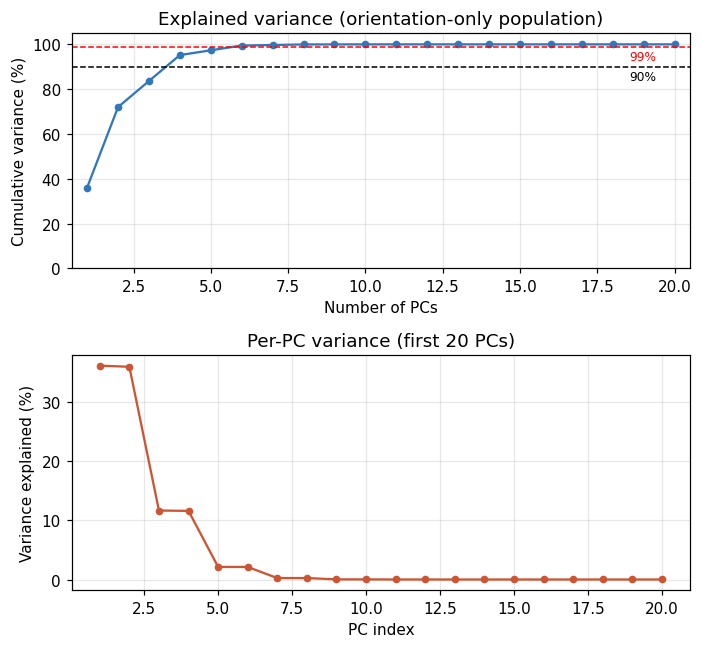

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(6.5, 6))

n_show = 20      # the remaining PCs are flat at ~100%, so there is nothing to see there
axes[0].plot(np.arange(1, n_show + 1), cum_expl_var[:n_show], "-o", ms=4, lw=1.5, color="#3377bb")
for level, color in [(90, "k"), (99, "r")]:
    axes[0].axhline(level, ls="--", color=color, lw=1)
    axes[0].text(n_show * 0.97, level - 6, f"{level}%", color=color, fontsize=8, ha="right")
axes[0].set(xlabel="Number of PCs", ylabel="Cumulative variance (%)", ylim=(0, 105),
            xlim=(0.5, n_show + 0.5),
            title="Explained variance (orientation-only population)")

axes[1].plot(np.arange(1, 21), expl_var[:20], "-o", ms=4, lw=1.5, color="#cc5533")
axes[1].set(xlabel="PC index", ylabel="Variance explained (%)",
            title="Per-PC variance (first 20 PCs)")
fig.tight_layout()

PC1 and PC2 carry roughly equal variance and together account for about 72%; six PCs reach
99%. Out of 300 neurons and 180 stimuli, the representation is effectively **six-dimensional**.

Why so few? Because all 300 neurons are tuned to orientation in the same smooth, periodic
way, so the population needs only a handful of "basis functions" to represent all 180
orientations. The **intrinsic dimensionality** of the representation is set by the stimulus
and the tuning curves, not by the number of neurons you happen to record.

The near-equal pairing of PC1 with PC2 is not a coincidence, and neither is the pairing of
PC3 with PC4. They are successive Fourier harmonics on the orientation circle, and each
harmonic needs both a cosine and a sine — hence pairs of equal variance. The next section
makes this explicit.

> ### Homework question 3
> **(a)** How many PCs are needed to explain 99% of the variance? Compare that to $N = 300$
> neurons and $S = 180$ stimuli. What does the comparison tell you?
>
> **(b)** Re-run with `kappa = 1` (broader tuning) and `kappa = 8` (sharper). How does the
> explained-variance plot change, and why?
>
> **(c)** Add noise before running PCA (`R_noisy = R + 0.1 * rng.standard_normal(R.shape)`).
> How does the scree plot change? What does that tell you about what PCA "sees" in noisy
> data?

### The orientation ring

Because orientation is periodic, we colour each stimulus with a **cyclic** colormap
(`hsv`), so that 0° and 180° receive nearly the same colour rather than opposite ends of a
gradient. Using a linear colormap here would draw a false discontinuity across a variable
that has none.

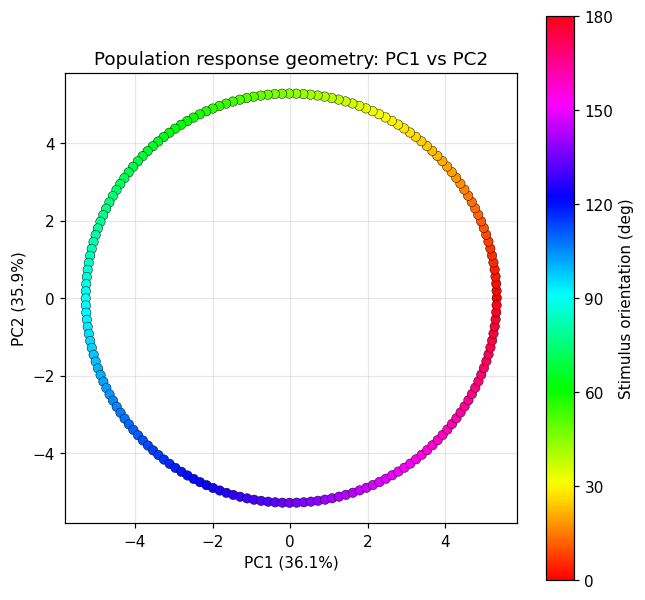

In [10]:
ori_colors = cm.hsv(stim_oris / 180.0)

fig, ax = plt.subplots(figsize=(6, 5.6))
ring = np.vstack([score[:, :2], score[0, :2]])         # close the loop
ax.plot(ring[:, 0], ring[:, 1], "-k", lw=0.8, zorder=1)
sc = ax.scatter(score[:, 0], score[:, 1], s=38, c=stim_oris, cmap="hsv",
                vmin=0, vmax=180, edgecolors="k", linewidths=0.3, zorder=2)
ax.set(xlabel=f"PC1 ({expl_var[0]:.1f}%)", ylabel=f"PC2 ({expl_var[1]:.1f}%)",
       title="Population response geometry: PC1 vs PC2", aspect="equal")
cb = fig.colorbar(sc, ax=ax, ticks=np.arange(0, 181, 30))
cb.set_label("Stimulus orientation (deg)")
fig.tight_layout()

The population response traces out a **ring** in PC1–PC2 space: the *orientation manifold*.

Why a ring? Orientation is periodic. As the stimulus rotates from 0° to 180°, the population
activity vector rotates through neuron space and returns to where it started, so in PC space
it sweeps out a closed loop. The loop is close to circular because von Mises tuning is
smooth and every preferred orientation is equally represented.

Note what this means: the *stimulus* is a one-dimensional variable, but the manifold it
generates is a one-dimensional curve embedded in a **two**-dimensional plane. A periodic
variable cannot be laid out on a line without a cut, so the population needs two dimensions
to represent one circular quantity.

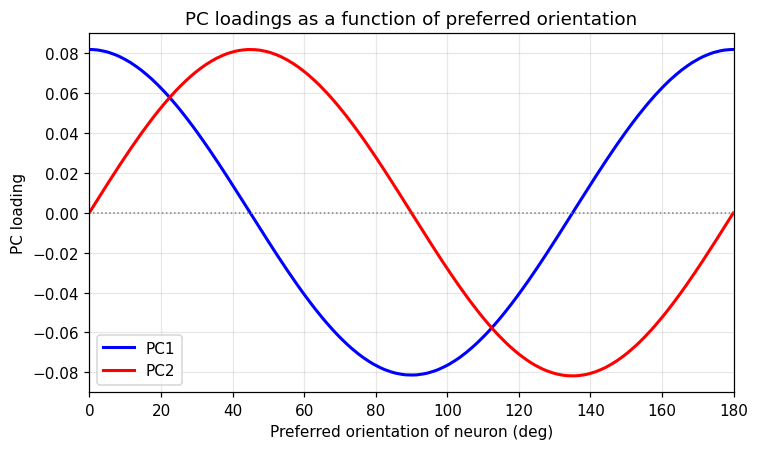

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(pref_oris, coeff[:, 0], "b-", lw=2, label="PC1")
ax.plot(pref_oris, coeff[:, 1], "r-", lw=2, label="PC2")
ax.axhline(0, color="0.5", ls=":", lw=1)
ax.set(xlabel="Preferred orientation of neuron (deg)", ylabel="PC loading",
       title="PC loadings as a function of preferred orientation", xlim=(0, 180))
ax.legend()
fig.tight_layout()

PC1 and PC2 are **sinusoids** — a cosine and a sine — as functions of preferred orientation.
That is, they are the first two Fourier components on the orientation circle. Together they
form a 2-D coordinate system in which orientation is simply an *angle*, so decoding the
stimulus reduces to computing $\operatorname{atan2}(\text{score}_2, \text{score}_1)$.

Let us check that the stimulus really can be recovered from those two numbers alone.

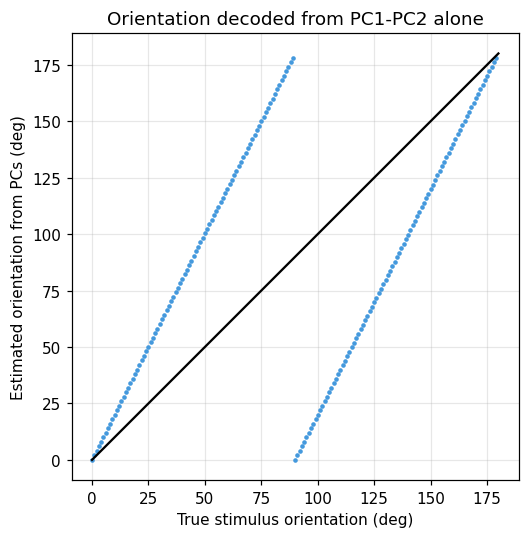

In [12]:
est_ori = np.rad2deg(np.arctan2(score[:, 1], score[:, 0])) % 360
est_ori = est_ori % 180        # orientation is 180-deg periodic, atan2 spans 360

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(stim_oris, est_ori, ".", ms=4, color="#4499dd")
ax.plot([0, 180], [0, 180], "-k", lw=1.5)
ax.set(xlabel="True stimulus orientation (deg)",
       ylabel="Estimated orientation from PCs (deg)",
       title="Orientation decoded from PC1-PC2 alone", aspect="equal")
fig.tight_layout()

The decoded values fall on a straight line, possibly offset or reflected depending on the
arbitrary sign and starting phase of the PCs.

> ### Homework question 4
> **(a)** Why does the decoded orientation show a discontinuity or "fold"? What is the
> relationship between the 180° periodicity of orientation and the 360° range of `atan2`?
>
> **(b)** How would you modify the decoding to handle the 180°-vs-360° ambiguity cleanly?
> *Hint:* think about where the factor of $2\theta$ in the tuning curve went.
>
> **(c)** If you added a population of neurons tuned to colour rather than orientation,
> where in PC space would colour responses appear? What would the scree plot look like?

### Effect of tuning width on population geometry

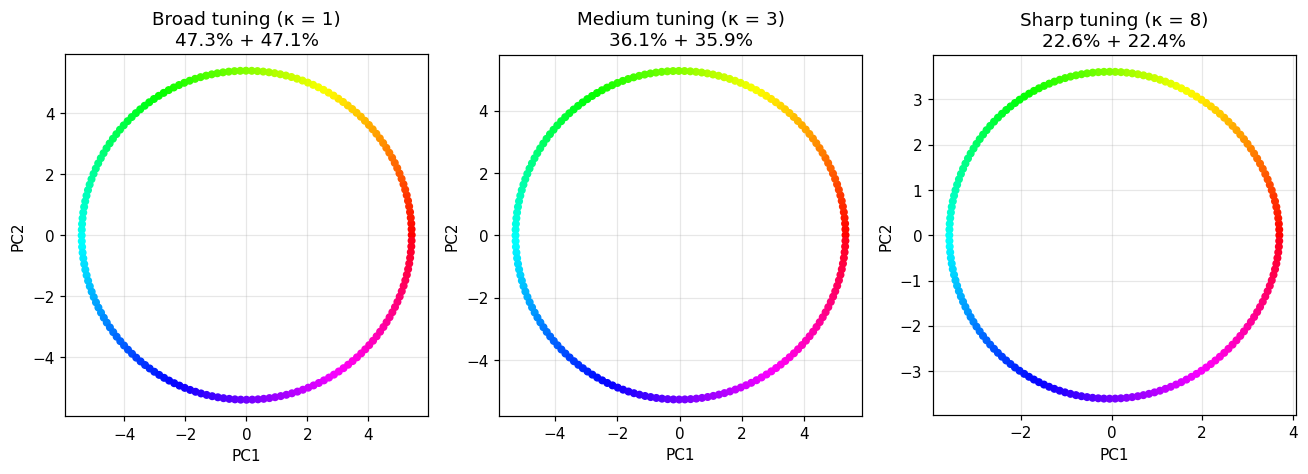

In [13]:
kappa_vals = [1.0, 3.0, 8.0]
titles = ["Broad tuning (κ = 1)", "Medium tuning (κ = 3)", "Sharp tuning (κ = 8)"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, kv, title in zip(axes, kappa_vals, titles):
    Rv = population_response(pref_oris, kv, stim_oris, baseline, gain)
    Xv = Rv.T - Rv.T.mean(axis=0)
    p = PCA(n_components=3)
    sv = p.fit_transform(Xv)
    ev = 100 * p.explained_variance_ / np.sum(np.var(Xv, axis=0, ddof=1))

    loop = np.vstack([sv[:, :2], sv[0, :2]])
    ax.plot(loop[:, 0], loop[:, 1], "-k", lw=0.8, zorder=1)
    ax.scatter(sv[:, 0], sv[:, 1], s=18, c=stim_oris, cmap="hsv", vmin=0, vmax=180, zorder=2)
    ax.set(xlabel="PC1", ylabel="PC2", aspect="equal",
           title=f"{title}\n{ev[0]:.1f}% + {ev[1]:.1f}%")
fig.tight_layout()

All three populations form a ring, but the variance is distributed differently. With
**sharper** tuning each neuron responds to fewer stimuli, the responses are more sharply
peaked, and higher PCs carry more variance — the ring is "rougher", because reproducing a
narrow bump requires more Fourier components. With **broader** tuning the responses are
smoother and nearly all variance collapses into the first two PCs.

---
## Part IV. Two-dimensional stimuli: orientation × spatial frequency

Real visual neurons are tuned to both orientation **and** spatial frequency (SF). A neuron
preferring vertical gratings at 2 c/deg responds poorly to horizontal gratings and poorly to
very low or very high spatial frequencies.

We model SF tuning as Gaussian in $\log_{10}$ SF — the standard description, since SF
bandwidth is roughly constant in octaves rather than in cycles/deg — and take the response
to be the product of the two tuning functions:

$$R = \text{baseline} + \text{gain} \cdot
      \underbrace{\exp[\kappa\cos(2(\theta - \phi))]}_{\text{orientation}} \cdot
      \underbrace{\exp\!\left[-\frac{(\log_{10} f - \log_{10} f_0)^2}{2\sigma^2}\right]}_{\text{spatial frequency}}$$

When both stimulus dimensions vary, the population traces out a more complex surface.

In [20]:
N_ori, N_sf = 80, 10                    # preferred orientations x preferred SFs
N2 = N_ori * N_sf

pref_oris2_base = np.linspace(0, 179.9, N_ori)
sf_grid_base    = np.logspace(-2, 1, N_sf)         # 0.01 to 10 c/deg

ori_idx, sf_idx = np.meshgrid(np.arange(N_ori), np.arange(N_sf), indexing="ij")
pref_oris2 = pref_oris2_base[ori_idx.ravel()]      # (N2,)
pref_sfs2  = sf_grid_base[sf_idx.ravel()]          # (N2,)

# Stimulus grid: every orientation x SF combination
stim_oris2 = np.arange(0, 180, 15.0)               # 12 orientations
stim_sfs2  = np.logspace(-2, 1, 8)                 # 8 spatial frequencies
o_sg, f_sg = np.meshgrid(np.arange(stim_oris2.size), np.arange(stim_sfs2.size), indexing="ij")
stim_ori_list = stim_oris2[o_sg.ravel()]
stim_sf_list  = stim_sfs2[f_sg.ravel()]
n_cond2 = stim_ori_list.size

kappa2, sf_sigma2 = 3.0, 0.5

def ori_sf_response(stim_ori_list, stim_sf_list, sf_gain_neuron=None):
    '''Population response to every (orientation, SF) condition. Returns (N2, n_cond).

    sf_gain_neuron optionally scales each neuron's SF tuning (used in Part V).
    '''
    dtheta = (np.deg2rad(stim_ori_list)[None, :] - np.deg2rad(pref_oris2)[:, None])
    ori_tuning = np.exp(kappa2 * np.cos(2 * dtheta))

    dlog_sf = (np.log10(stim_sf_list)[None, :] - np.log10(pref_sfs2)[:, None])
    sf_tuning = np.exp(-(dlog_sf ** 2) / (2 * sf_sigma2 ** 2))
    if sf_gain_neuron is not None:
        sf_tuning = sf_gain_neuron[:, None] * sf_tuning

    return baseline + gain * (ori_tuning * sf_tuning)

R2 = ori_sf_response(stim_ori_list, stim_sf_list)
print(f"Orientation x SF population: {N2} neurons, {n_cond2} stimulus conditions")

X2c = R2.T - R2.T.mean(axis=0)
pca2 = PCA()
score2 = pca2.fit_transform(X2c)
expl_var2 = 100 * pca2.explained_variance_ / pca2.explained_variance_.sum()
print("Top 5 PCs explain: " + ", ".join(f"{v:.1f}%" for v in expl_var2[:5]))

Orientation x SF population: 800 neurons, 96 stimulus conditions
Top 5 PCs explain: 13.6%, 13.3%, 13.0%, 8.6%, 8.4%


Now we need to show two stimulus dimensions at once. We map **orientation to hue** (cyclic,
as before) and **spatial frequency to saturation** — pale points are low SF, vivid points
high SF. Encoding a second variable in saturation rather than a second hue keeps the
periodic variable's colour identity intact.

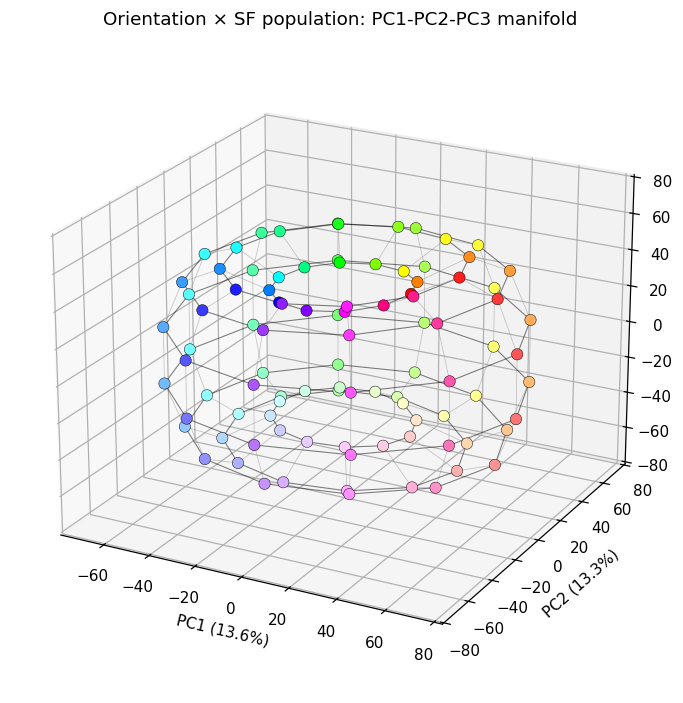

In [21]:
import matplotlib.colors as mcolors

hue = stim_ori_list / 180.0
sf_norm = (np.log10(stim_sf_list) - np.log10(stim_sfs2).min()) / np.ptp(np.log10(stim_sfs2))
saturation = 0.2 + 0.8 * sf_norm
colors2 = mcolors.hsv_to_rgb(np.column_stack([hue, saturation, np.ones(n_cond2)]))

fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(111, projection="3d")
plot_manifold(ax, score2, colors2, stim_oris2.size, stim_sfs2.size)
ax.set_xlabel(f"PC1 ({expl_var2[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({expl_var2[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({expl_var2[2]:.1f}%)", labelpad=8)
ax.set_title("Orientation × SF population: PC1-PC2-PC3 manifold")
set_axes_equal(ax)
fig.tight_layout()

With two stimulus dimensions the manifold is no longer a simple ring. It becomes
**torus-like**: orientation wraps around one direction — the ring we saw before — while SF
moves along the other. Rotate the plot (in JupyterLab, `%matplotlib widget` makes it
interactive) and the two families of curves become clear.

The consequence for dimensionality is direct: a second stimulus dimension demands more PCs.

PCs for 90% variance -- orientation only: 4, orientation x SF: 15


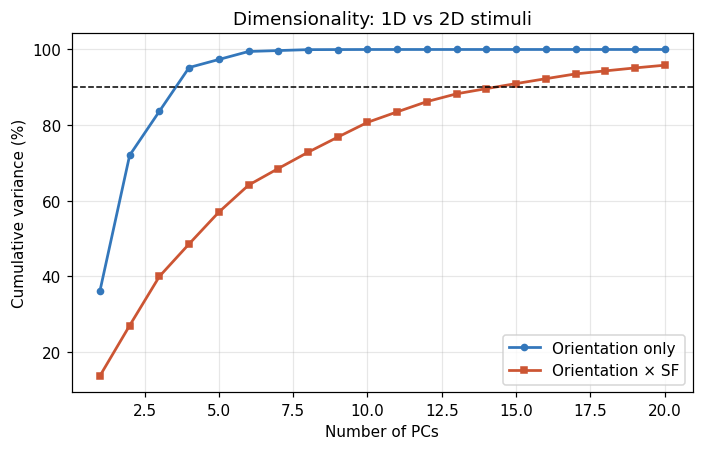

In [22]:
cum2 = np.cumsum(expl_var2)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(np.arange(1, 21), cum_expl_var[:20], "-o", ms=4, lw=1.8,
        color="#3377bb", label="Orientation only")
ax.plot(np.arange(1, 21), cum2[:20], "-s", ms=4, lw=1.8,
        color="#cc5533", label="Orientation × SF")
ax.axhline(90, ls="--", color="k", lw=1)
ax.set(xlabel="Number of PCs", ylabel="Cumulative variance (%)",
       title="Dimensionality: 1D vs 2D stimuli")
ax.legend(loc="lower right")
fig.tight_layout()

print(f"PCs for 90% variance -- orientation only: {np.searchsorted(cum_expl_var, 90) + 1}, "
      f"orientation x SF: {np.searchsorted(cum2, 90) + 1}")

> ### Homework question 5
> **(a)** Why does the 2-D stimulus set need more PCs to reach 90% variance? Relate your
> answer to the intrinsic dimensionality of the stimulus space.
>
> **(b)** If you recorded a real V1 population with random stimuli (pink-noise images),
> would you expect the scree plot to decay faster or slower than the orientation-only case?
> Why?
>
> **(c)** How would the manifold change if every neuron had the same preferred SF
> (`N_sf = 1`)? Predict the scree plot, then verify it in code.

---
## Part V. Fixed-axis projection: comparing two populations

A powerful use of PCA is to compare how a population responds under two different
conditions — before and after learning, attended and unattended, control and drug.

The naive approach is to run PCA separately on each condition. **This does not work**, and
the reason is worth internalizing: PCA chooses its axes from the data, so the two conditions
get *different* coordinate systems. Any apparent difference between the two plots then
confounds a real change in the population code with an arbitrary re-rotation of the axes.
The two pictures are not in the same space, so they cannot be compared.

The fix is a **fixed-axis projection**: define the axes once from a reference condition, then
project *both* conditions onto those same axes, using the reference mean for centering as
well. Differences that survive are differences in the population response.

Our test case is a cardinal–oblique anisotropy: neurons preferring cardinal orientations
(0° and 90°) get a boost in SF gain relative to those preferring obliques (45°, 135°). Such
anisotropies are well documented in visual cortex and in psychophysics.

In [23]:
sf_gain_amp = 0.5     # strength of the cardinal bias

# cos(2*theta)^2 peaks at 0 and 90 deg (cardinals), and is zero at 45 and 135 (obliques)
cardinal_mod = 1 + sf_gain_amp * np.cos(2 * np.deg2rad(pref_oris2)) ** 2

R_base = R2                                            # baseline (already computed)
R_bias = ori_sf_response(stim_ori_list, stim_sf_list, sf_gain_neuron=cardinal_mod)

# Step 1: PC axes and mean come from the BASELINE condition only
X_base  = R_base.T
base_mean = X_base.mean(axis=0)
pca_base = PCA()
score_base  = pca_base.fit_transform(X_base - base_mean)
coeff_base  = pca_base.components_.T
expl_base   = 100 * pca_base.explained_variance_ / pca_base.explained_variance_.sum()

# Step 2: project the biased condition using the SAME mean and the SAME axes
X_bias = R_bias.T
score_bias_fixed = (X_bias - base_mean) @ coeff_base     # note: baseline mean, not its own

print("Baseline PC1-3 variance: " + ", ".join(f"{v:.1f}%" for v in expl_base[:3]))

Baseline PC1-3 variance: 13.6%, 13.3%, 13.0%


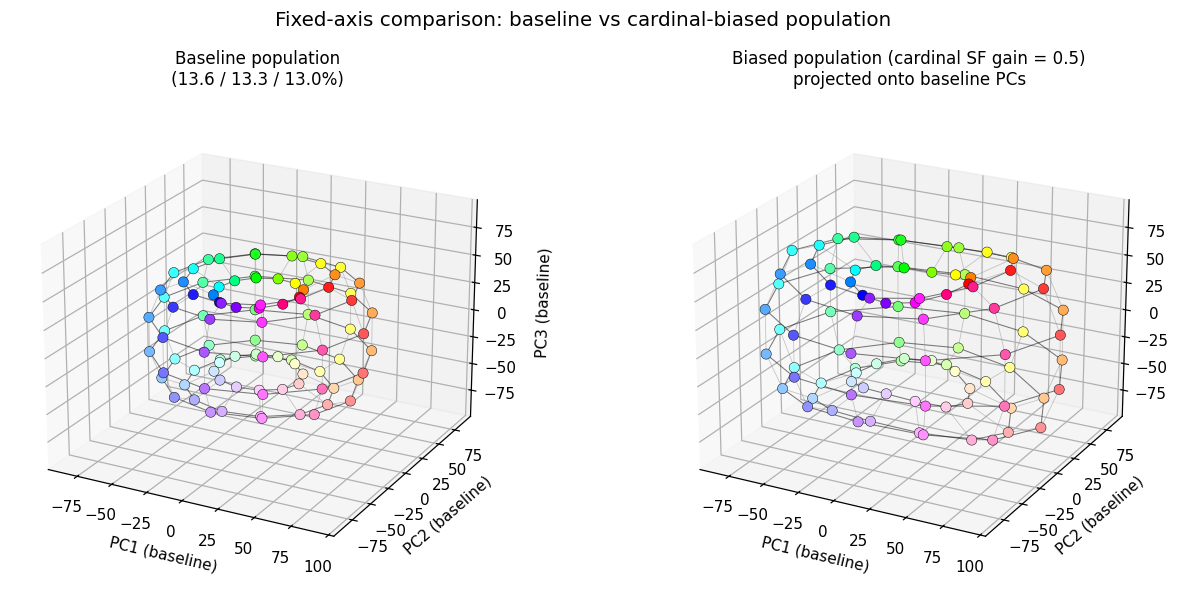

In [24]:
# Both panels must span the SAME range, or the eye compares two different
# zoom levels and the whole point of a fixed-axis projection is lost.
shared = np.vstack([score_base[:, :3], score_bias_fixed[:, :3]])

fig = plt.figure(figsize=(12, 5.5))
for k, (sc_data, title) in enumerate([
        (score_base, f"Baseline population\n({expl_base[0]:.1f} / {expl_base[1]:.1f} / {expl_base[2]:.1f}%)"),
        (score_bias_fixed, f"Biased population (cardinal SF gain = {sf_gain_amp})\nprojected onto baseline PCs")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    plot_manifold(ax, sc_data, colors2, stim_oris2.size, stim_sfs2.size, s=45)
    ax.set_xlabel("PC1 (baseline)"); ax.set_ylabel("PC2 (baseline)")
    ax.set_zlabel("PC3 (baseline)", labelpad=8)
    ax.set_title(title, fontsize=11)
    set_axes_equal(ax, data=shared)          # identical limits on both panels
fig.suptitle("Fixed-axis comparison: baseline vs cardinal-biased population", fontsize=13)
fig.tight_layout()

Because both panels live in the *same* coordinate system, the change in shape is directly
interpretable. Conditions whose neurons received the extra gain are displaced; obliques are
comparatively unchanged.

Rather than judging that by eye, quantify it: for each stimulus condition, measure how far
the biased population lands from the baseline population in the top-3-PC subspace.

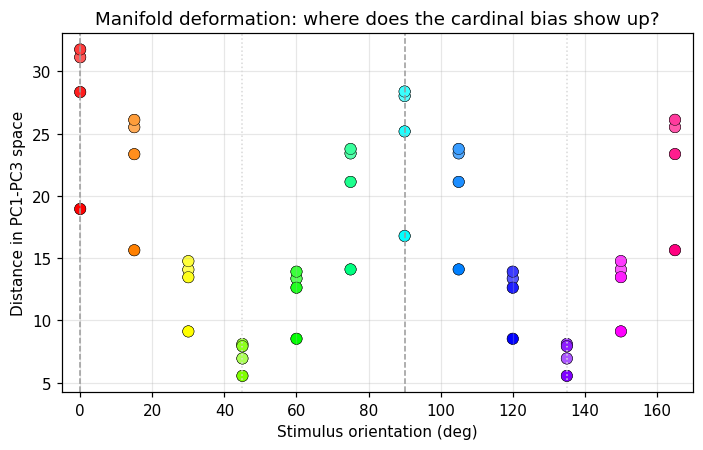

In [25]:
dist_pc3 = np.linalg.norm(score_base[:, :3] - score_bias_fixed[:, :3], axis=1)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(stim_ori_list, dist_pc3, s=55, c=colors2, edgecolors="k", linewidths=0.3)
for x in (0, 90):
    ax.axvline(x, color="0.6", ls="--", lw=1)
for x in (45, 135):
    ax.axvline(x, color="0.85", ls=":", lw=1)
ax.set(xlabel="Stimulus orientation (deg)",
       ylabel="Distance in PC1-PC3 space",
       title="Manifold deformation: where does the cardinal bias show up?",
       xlim=(-5, 170))
fig.tight_layout()

The deformation is largest at the cardinal orientations (dashed lines, 0° and 90°) and
smallest at the obliques (dotted lines, 45° and 135°) — exactly the anisotropy we built into
the simulation, now recovered as a geometric signature at the population level. The vertical
spread at each orientation comes from the different spatial frequencies, since the bias acts
on SF gain.

> ### Homework question 6
> **(a)** Vary `sf_gain_amp` from 0 to 2. How does the comparison figure change? Is there a
> threshold below which the bias is undetectable by eye in the PC plot but still visible in
> the distance plot?
>
> **(b)** The fixed-axis projection subtracts the **baseline** mean before projecting.
> What would happen if you subtracted the biased population's own mean instead? Would the
> comparison still be valid? When might you prefer each choice?
>
> **(c)** Build a biased population whose bias affects only low-SF responses. Predict how
> the two figures above would look, then verify with code.

---
## Summary

1. Neural population responses form **low-dimensional manifolds** inside the
   high-dimensional space of all possible population states.

2. The **covariance matrix** captures pairwise relationships between neurons. Its
   eigenvectors define the natural axes (the PCs); its eigenvalues give the variance along
   each one.

3. For an orientation-tuned population, PCA recovers a **ring** in PC1–PC2 space, reflecting
   the 180° periodicity of the stimulus. PC1 and PC2 carry cosine and sine loadings over
   preferred orientation, so orientation can be decoded as an angle in that plane.

4. Adding a second stimulus dimension expands the manifold from a **ring to a torus** and
   raises the number of PCs needed to capture the variance.

5. **Fixed-axis projection** — taking axes and mean from a reference condition and
   projecting a second condition onto them — makes population geometry comparable across
   conditions, which separate PCAs cannot do.

A caution to carry forward: PCA orders directions by **variance**, and variance is not the
same thing as relevance. The largest source of variance in a real recording is often a
shared gain fluctuation that carries no stimulus information at all. The classification
tutorial (`ClassificationTutorial.m`) takes up exactly this point.

### Further reading

- Cunningham & Yu (2014). Dimensionality reduction for large-scale neural recordings.
  *Nature Neuroscience* **17**, 1500–1509.
- Jazayeri & Ostojic (2021). Interpreting neural computations by examining intrinsic and
  embedding dimensionality. *Current Opinion in Neurobiology* **70**, 113–120.
- Rieke et al., `PCATutorial.m` (this course) — PCA applied to rod photoreceptor
  single-photon responses.